Dataset Columns: Index(['QuoteID', 'QuoteVersion', 'QuoteDate', 'ExpirationDate',
       'SalesPersonID', 'SalesPersonName', 'CustomerID', 'CustomerName',
       'BranchName', 'Ship2City', 'Ship2State', 'ProductID', 'ProductGroupID',
       'QuoteQty', 'UnitPrice', 'UOM', 'UnitSize', 'QuoteStatus',
       'ConvertedToOrderNumber', 'ConversionDate', 'CustomerTier'],
      dtype='object')
Accuracy: 0.7698
Classification Report:
              precision    recall  f1-score   support

        Lost     1.0000    0.2584    0.4106    109339
         Won     0.7498    1.0000    0.8570    242977

    accuracy                         0.7698    352316
   macro avg     0.8749    0.6292    0.6338    352316
weighted avg     0.8274    0.7698    0.7185    352316


Confusion Matrix:
[[ 28249  81090]
 [     0 242977]]

Cross-Validation Accuracy: 0.66 ± 0.15


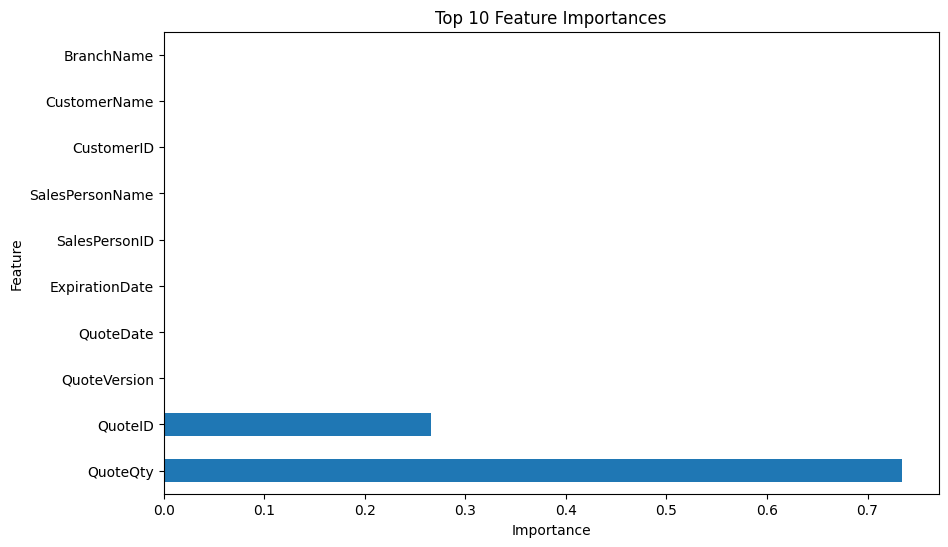


Decision Tree Rules:
|--- QuoteQty <= 1.00
|   |--- class: Lost
|--- QuoteQty >  1.00
|   |--- QuoteQty <= 1.00
|   |   |--- class: Won
|   |--- QuoteQty >  1.00
|   |   |--- QuoteQty <= 2.00
|   |   |   |--- class: Lost
|   |   |--- QuoteQty >  2.00
|   |   |   |--- QuoteID <= 1695000.00
|   |   |   |   |--- QuoteID <= 99999.50
|   |   |   |   |   |--- class: Won
|   |   |   |   |--- QuoteID >  99999.50
|   |   |   |   |   |--- class: Won
|   |   |   |--- QuoteID >  1695000.00
|   |   |   |   |--- QuoteID <= 1739999.50
|   |   |   |   |   |--- class: Lost
|   |   |   |   |--- QuoteID >  1739999.50
|   |   |   |   |   |--- class: Won



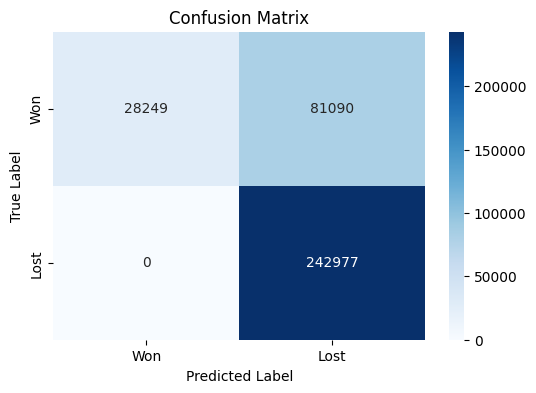

C:\Users\nhail\AppData\Local\Temp\ipykernel_12336\4236608527.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance_df.head(15), x='Importance', y='Feature', palette='viridis')


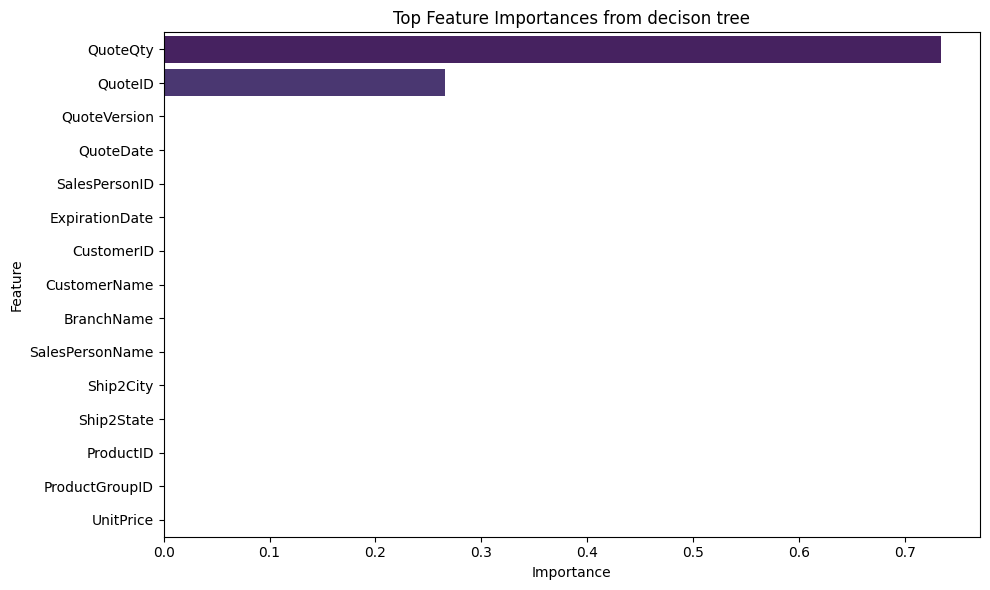

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.tree import export_graphviz
import graphviz
import seaborn as sns
# Load the dataset
df = pd.read_csv("../../Dataset/quotes_customer_tier.csv")
print("Dataset Columns:", df.columns)

leakage_cols = [ 'ConvertedToOrderNumber', 'ConversionDate']
df = df.drop(columns=leakage_cols, errors='ignore')

# Remove rows where 'QuoteStatus' is 'Revised'
df = df[df['QuoteStatus'] != 'Revised']

# Define features and target (target remains as string "Won" and "Lost")
X = df.drop(columns=['QuoteStatus'], errors='ignore')
y = df['QuoteStatus']

# Identify categorical columns in X and apply Label Encoding
categorical_cols = X.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Split data into training and testing sets (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Initialize and train Decision Tree Classifier with a limited depth to avoid overfitting
clf = DecisionTreeClassifier(random_state=42, max_depth=5)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)


# Print Accuracy (four decimal places) and Classification Report
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
# We specify labels=["Lost", "Won"] to ensure the order (Lost -> 0, Won -> 1)
# 'digits=4' ensures four decimal places in the report
print(classification_report(y_test, y_pred, labels=["Lost", "Won"], digits=4))


# (Optional) Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["Lost", "Won"])
print("\nConfusion Matrix:")
print(cm)

# (Optional) Cross-Validation
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy: %.2f ± %.2f" % (cv_scores.mean(), cv_scores.std()))


# (Optional) Visualize Feature Importances
feat_importances = pd.Series(clf.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


# (Optional) Print Decision Tree Rules
tree_rules = export_text(clf, feature_names=list(X.columns))
print("\nDecision Tree Rules:")
print(tree_rules)

from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(clf,
                           out_file=None,
                           feature_names=X.columns,
                           class_names=clf.classes_,
                           filled=True,
                           rounded=True,
                           special_characters=True)

graph = graphviz.Source(dot_data)
graph.render("decision_tree")  # Saves the file (e.g., as PDF)
graph  # In a Jupyter Notebook, this displays the tree
# Plot Feature Importances
importances = clf.feature_importances_
feature_names = X.columns

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top Feature Importances from decison tree')
plt.tight_layout()
plt.show()
